In [36]:
# Installing necessary libraries 

import nltk
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import requests
from nltk.corpus import stopwords
import re

In [76]:
# Downloading NLTK stopwords
nltk.download('stopwords')

# Load text data from URL
url = "http://www.sthda.com/sthda/RDoc/example-files/martin-luther-king-i-have-a-dream-speech.txt"
response = requests.get(url)
text = response.text


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/shraddha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [78]:

print(text)


And so even though we face the difficulties of today and tomorrow, I still have a dream. It is a dream deeply rooted in the American dream.
 
I have a dream that one day this nation will rise up and live out the true meaning of its creed:
 
We hold these truths to be self-evident, that all men are created equal.
 
I have a dream that one day on the red hills of Georgia, the sons of former slaves and the sons of former slave owners will be able to sit down together at the table of brotherhood.
 
I have a dream that one day even the state of Mississippi, a state sweltering with the heat of injustice, sweltering with the heat of oppression, will be transformed into an oasis of freedom and justice.
 
I have a dream that my four little children will one day live in a nation where they will not be judged by the color of their skin but by the content of their character.
 
I have a dream today!
 
I have a dream that one day, down in Alabama, with its vicious racists, with its governor having 

In [84]:
#Missing values in training set
#text.isnull().sum()

AttributeError: 'str' object has no attribute 'isnull'

In [86]:
# Define a function to clean the text
def clean_text(text):
    # Replace specific characters with space
    text = re.sub(r'[\/@|]', ' ', text)
    # Convert to lower case
    text = text.lower()
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Clean the text
cleaned_text = clean_text(text)

In [88]:
# Remove stopwords
stop_words = set(stopwords.words('english'))
cleaned_text = ' '.join([word for word in cleaned_text.split() if word not in stop_words])

# Convert text to a document-term matrix
vectorizer = CountVectorizer()
dtm = vectorizer.fit_transform([cleaned_text])
dtm_matrix = dtm.toarray()

# Get the frequency of each word
word_freq = dict(zip(vectorizer.get_feature_names_out(), dtm_matrix[0]))
sorted_word_freq = dict(sorted(word_freq.items(), key=lambda item: item[1], reverse=True))

# Create a dataframe to show top 10 frequent words
import pandas as pd
df = pd.DataFrame(list(sorted_word_freq.items()), columns=['word', 'freq'])
print(df.head(10))

       word  freq
0   freedom    13
1      ring    12
2       day    11
3     dream    11
4       let    11
5     every     9
6      able     8
7       one     8
8  together     7
9     faith     4


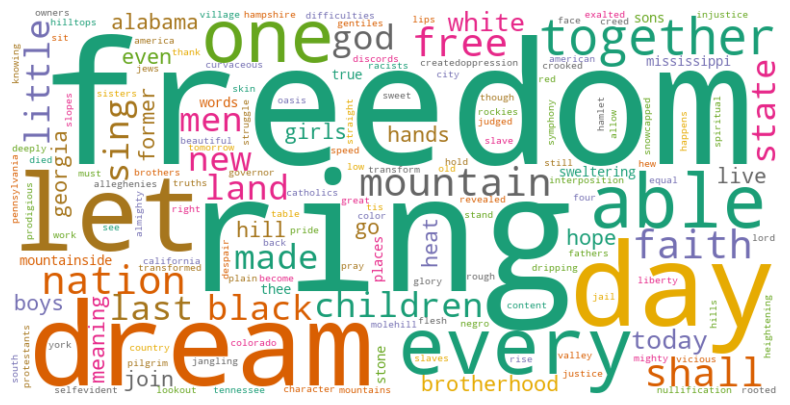

Frequent terms with frequency >= 4: {'freedom': 13, 'ring': 12, 'day': 11, 'dream': 11, 'let': 11, 'every': 9, 'able': 8, 'one': 8, 'together': 7, 'faith': 4, 'free': 4, 'mountain': 4, 'nation': 4, 'shall': 4}
'freedom' appears 13 times in the text.


In [90]:
# Generate and plot word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200, random_state=1234, colormap='Dark2').generate_from_frequencies(sorted_word_freq)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Find terms with a frequency of 4 or higher
frequent_terms = {k: v for k, v in sorted_word_freq.items() if v >= 4}
print(f"Frequent terms with frequency >= 4: {frequent_terms}")

# Find words associated with "freedom"
# Calculate the correlation of "freedom" with other terms (a basic example, not direct term association)
if 'freedom' in word_freq:
    print(f"'freedom' appears {word_freq['freedom']} times in the text.")
else:
    print("'freedom' is not present in the text.")

In [98]:
#Tokenisation

tokenizer1 = nltk.tokenize.WhitespaceTokenizer()
tokenizer2 = nltk.tokenize.TreebankWordTokenizer()
tokenizer3 = nltk.tokenize.WordPunctTokenizer()
tokenizer4 = nltk.tokenize.RegexpTokenizer(r'\w+')

print("Example Text: ",text)
print("------------------------------------------------------------------------------------------------")
print("Tokenization by whitespace:- \n",tokenizer1.tokenize(text))
print("Tokenization by words using Treebank Word Tokenizer:- \n",tokenizer2.tokenize(text))
print("Tokenization by punctuation:- \n",tokenizer3.tokenize(text))
print("Tokenization by regular expression:- ",tokenizer4.tokenize(text))

Example Text:  
And so even though we face the difficulties of today and tomorrow, I still have a dream. It is a dream deeply rooted in the American dream.
 
I have a dream that one day this nation will rise up and live out the true meaning of its creed:
 
We hold these truths to be self-evident, that all men are created equal.
 
I have a dream that one day on the red hills of Georgia, the sons of former slaves and the sons of former slave owners will be able to sit down together at the table of brotherhood.
 
I have a dream that one day even the state of Mississippi, a state sweltering with the heat of injustice, sweltering with the heat of oppression, will be transformed into an oasis of freedom and justice.
 
I have a dream that my four little children will one day live in a nation where they will not be judged by the color of their skin but by the content of their character.
 
I have a dream today!
 
I have a dream that one day, down in Alabama, with its vicious racists, with its g

In [108]:
# Stemming and Lemmatization examples

tokenizer = nltk.tokenize.TreebankWordTokenizer()
tokens = tokenizer.tokenize(text)

# Stemmer
stemmer = nltk.stem.PorterStemmer()
print("Stemming the sentence: ", " ".join(stemmer.stem(token) for token in tokens))

Stemming the sentence:  and so even though we face the difficulti of today and tomorrow , i still have a dream. it is a dream deepli root in the american dream. i have a dream that one day thi nation will rise up and live out the true mean of it creed : we hold these truth to be self-evid , that all men are creat equal. i have a dream that one day on the red hill of georgia , the son of former slave and the son of former slave owner will be abl to sit down togeth at the tabl of brotherhood. i have a dream that one day even the state of mississippi , a state swelter with the heat of injustic , swelter with the heat of oppress , will be transform into an oasi of freedom and justice. i have a dream that my four littl children will one day live in a nation where they will not be judg by the color of their skin but by the content of their character. i have a dream today ! i have a dream that one day , down in alabama , with it viciou racist , with it governor have hi lip drip with the word 

In [110]:
import nltk
from nltk.corpus import stopwords
nltk.download('wordnet')

# Lemmatizer
lemmatizer=nltk.stem.WordNetLemmatizer()
print("Lemmatizing the sentence: ", " ".join(lemmatizer.lemmatize(token) for token in tokens))

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/shraddha/nltk_data...


Lemmatizing the sentence:  And so even though we face the difficulty of today and tomorrow , I still have a dream. It is a dream deeply rooted in the American dream. I have a dream that one day this nation will rise up and live out the true meaning of it creed : We hold these truth to be self-evident , that all men are created equal. I have a dream that one day on the red hill of Georgia , the son of former slave and the son of former slave owner will be able to sit down together at the table of brotherhood. I have a dream that one day even the state of Mississippi , a state sweltering with the heat of injustice , sweltering with the heat of oppression , will be transformed into an oasis of freedom and justice. I have a dream that my four little child will one day live in a nation where they will not be judged by the color of their skin but by the content of their character. I have a dream today ! I have a dream that one day , down in Alabama , with it vicious racist , with it governor